In [2]:
import os
import math
import io
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class ImagePathsDataset(Dataset):
    """
    Dataset that loads images from a list of file paths,
    applies a transform, and returns (image_tensor, dummy_label).
    """
    def __init__(self, file_paths, transform=None):
        self.paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

In [4]:
dataset_root = r"C:\Users\pragnay\OneDrive\Documents\ImageResizer\data\myPhotos"

# Collect all image paths
all_files = []
for fname in os.listdir(dataset_root):
    if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        all_files.append(os.path.join(dataset_root, fname))

if len(all_files) == 0:
    raise RuntimeError(f"No images found in folder: {dataset_root}")

print(f"Found {len(all_files)} images in your folder.")

# Shuffle & split into train/val (e.g., 90% train, 10% val)
random.shuffle(all_files)
val_fraction = 0.1
val_count = max(1, int(len(all_files) * val_fraction))

val_files = all_files[:val_count]
train_files = all_files[val_count:]

print(f"Train images: {len(train_files)}, Val images: {len(val_files)}")

Found 620 images in your folder.
Train images: 558, Val images: 62


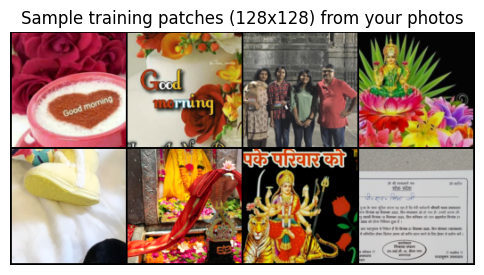

In [6]:
train_transform = T.Compose([
    T.Resize(192),                    # up/downscale to a consistent range
    T.RandomCrop(128),                # random 128x128 patch
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1, 0.1, 0.1, 0.05),
    T.ToTensor(),                     # [0,1]
])

val_transform = T.Compose([
    T.Resize(192),
    T.RandomCrop(128),
    T.ToTensor(),
])


train_set = ImagePathsDataset(train_files, transform=train_transform)
val_set   = ImagePathsDataset(val_files,   transform=val_transform)

batch_size = 8  # RTX 3050 should handle this at 128x128 with medium model

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Quick sanity check: visualize a batch
x,_ = next(iter(train_loader))
grid = vutils.make_grid(x[:8], nrow=4, normalize=True, value_range=(0,1))
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Sample training patches (128x128) from your photos")
plt.show()

In [7]:
class GaussianLikelihood(nn.Module):
    def forward(self, x, mu, sigma):
        sigma = torch.clamp(sigma, min=1e-5)
        return -0.5 * (((x - mu) / sigma)**2 + 2 * torch.log(sigma * (2 * np.pi)**0.5))

In [8]:
class AnalysisTransform(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   64, kernel_size=5, stride=2, padding=2)  # /2
        self.conv2 = nn.Conv2d(64,  96, kernel_size=5, stride=2, padding=2)  # /4
        self.conv3 = nn.Conv2d(96,  96, kernel_size=5, stride=2, padding=2)  # /8
        self.conv4 = nn.Conv2d(96,  96, kernel_size=5, stride=2, padding=2)  # /16

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.conv4(x)
        return x

In [9]:
class HyperAnalysis(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(96, 96, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(96, 96, kernel_size=5, stride=2, padding=2)  # /2
        self.conv3 = nn.Conv2d(96, 64, kernel_size=5, stride=2, padding=2)  # /4

    def forward(self, y):
        z = F.relu(self.conv1(y))
        z = F.relu(self.conv2(z))
        z = self.conv3(z)
        return z

In [10]:
class HyperSynthesis(nn.Module):
    def __init__(self):
        super().__init__()
        self.tconv1 = nn.ConvTranspose2d(64, 96, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.tconv2 = nn.ConvTranspose2d(96, 96, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.conv_out = nn.Conv2d(96, 192, kernel_size=3, stride=1, padding=1)  # 2 * 96 (mu+sigma)

    def forward(self, z_hat):
        h = F.relu(self.tconv1(z_hat))
        h = F.relu(self.tconv2(h))
        h = self.conv_out(h)
        mu_y, sigma_raw = torch.chunk(h, 2, dim=1)
        sigma_y = F.softplus(sigma_raw) + 1e-5
        return mu_y, sigma_y

In [11]:
class SynthesisTransform(nn.Module):
    def __init__(self):
        super().__init__()
        self.tconv1 = nn.ConvTranspose2d(96, 96, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.tconv2 = nn.ConvTranspose2d(96, 96, kernel_size=5, stride=2, padding=2, output_padding=1)  # x4
        self.tconv3 = nn.ConvTranspose2d(96, 64, kernel_size=5, stride=2, padding=2, output_padding=1)  # x8
        self.tconv4 = nn.ConvTranspose2d(64, 3,  kernel_size=5, stride=2, padding=2, output_padding=1)  # x16

    def forward(self, y_hat):
        x = F.relu(self.tconv1(y_hat))
        x = F.relu(self.tconv2(x))
        x = F.relu(self.tconv3(x))
        x = torch.sigmoid(self.tconv4(x))
        return x

In [12]:
class NeuralImageCodec(nn.Module):
    def __init__(self):
        super().__init__()
        self.g_a = AnalysisTransform()
        self.h_a = HyperAnalysis()
        self.h_s = HyperSynthesis()
        self.g_s = SynthesisTransform()
        self.gauss = GaussianLikelihood()

    def forward(self, x, training=True):
        # Encoder
        y = self.g_a(x)
        z = self.h_a(y)

        if training:
            y_hat = y + (torch.rand_like(y) - 0.5)
            z_hat = z + (torch.rand_like(z) - 0.5)
        else:
            y_hat = torch.round(y)
            z_hat = torch.round(z)

        mu_y, sigma_y = self.h_s(z_hat)
        x_hat = self.g_s(y_hat)

        return y_hat, z_hat, mu_y, sigma_y, x_hat


In [13]:
model = NeuralImageCodec().to(device)
num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {num_params:.2f} M")


Model parameters: 2.26 M


In [14]:
import zlib

@torch.no_grad()
def compress_image_with_zlib(model, img_tensor):
    """
    img_tensor: (1,3,H,W) in [0,1], on device
    Returns: x_hat, theoretical_bpp, actual_bpp_zlib, compressed_bytes_len
    """
    model.eval()
    B, C, H, W = img_tensor.shape
    assert B == 1, "Use batch size 1 for single-image compression"

    
    y = model.g_a(img_tensor)
    z = model.h_a(y)
    y_hat = torch.round(y)
    z_hat = torch.round(z)
    mu_y, sigma_y = model.h_s(z_hat)
    x_hat = model.g_s(y_hat)

    
    log_p_y = model.gauss(y_hat, mu_y, sigma_y)
    log_p_z = -0.5 * (z_hat**2 + np.log(2*np.pi))
    num_pixels = H * W

    R_y = -torch.sum(log_p_y) / (num_pixels * log2)
    R_z = -torch.sum(log_p_z) / (num_pixels * log2)
    theoretical_bpp = (R_y + R_z).item()

    
    y_int = y_hat.cpu().short().numpy()   
    z_int = z_hat.cpu().short().numpy()

    
    import struct
    y_shape = y_int.shape  
    z_shape = z_int.shape  

    header = struct.pack("8i",
                         H, W,
                         y_shape[0], y_shape[1], y_shape[2],
                         z_shape[0], z_shape[1], z_shape[2])

    y_bytes = y_int.tobytes()
    z_bytes = z_int.tobytes()

    raw_stream = header + y_bytes + z_bytes

    compressed = zlib.compress(raw_stream, level=9)
    compressed_size_bytes = len(compressed)

    actual_bpp = (compressed_size_bytes * 8) / num_pixels

    return x_hat.cpu(), theoretical_bpp, actual_bpp, compressed_size_bytes


In [15]:
log2 = math.log(2.0)

def bits_per_pixel(log_prob, num_pixels, batch_size):
    # log_prob is log p(x) in natural log
    total_log_prob = torch.sum(log_prob)
    bpp = - total_log_prob / (batch_size * num_pixels * log2)
    return bpp

def train_one_epoch(model, loader, optimizer, lambda_rd=0.01):
    model.train()
    total_loss = total_D = total_R = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        y_t, z_t, mu, sigma, x_hat = model(x, training=True)

        # Rate term (y | mu, sigma)
        log_p_y = model.gauss(y_t, mu, sigma)

        # Prior for z: N(0,1)
        log_p_z = -0.5 * (z_t**2 + math.log(2 * math.pi))

        R_y = bits_per_pixel(log_p_y, num_pixels, B)
        R_z = bits_per_pixel(log_p_z, num_pixels, B)
        R = R_y + R_z

        # Distortion (L1)
        D = torch.mean(torch.abs(x - x_hat))

        loss = D + lambda_rd * R

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B
        total_D    += D.item() * B
        total_R    += R.item() * B
        count      += B

    return total_loss / count, total_D / count, total_R / count


@torch.no_grad()
def validate_one_epoch(model, loader, lambda_rd=0.01):
    model.eval()
    total_loss = total_D = total_R = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        # Deterministic quantization for val
        y_t, z_t, mu, sigma, x_hat = model(x, training=False)

        log_p_y = model.gauss(y_t, mu, sigma)
        log_p_z = -0.5 * (z_t**2 + math.log(2 * math.pi))

        R_y = bits_per_pixel(log_p_y, num_pixels, B)
        R_z = bits_per_pixel(log_p_z, num_pixels, B)
        R = R_y + R_z

        D = torch.mean(torch.abs(x - x_hat))
        loss = D + lambda_rd * R

        total_loss += loss.item() * B
        total_D    += D.item() * B
        total_R    += R.item() * B
        count      += B

    return total_loss / count, total_D / count, total_R / count


def save_checkpoint(model, optimizer, epoch, path="codec_checkpoint.pth"):
    state = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    torch.save(state, path)
    print(f"Checkpoint saved to {path}")


def load_checkpoint(model, optimizer, path="codec_checkpoint.pth"):
    state = torch.load(path, map_location=device)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    print(f"Loaded checkpoint from {path}, epoch {state['epoch']}")
    return state["epoch"]

In [16]:
lambda_rd = 0.004          # rate–distortion trade-off
num_epochs = 100000000          # increase later if you like
lr = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_hist = []   # (loss, D, R)
val_hist   = []

start_epoch = 1
resume = False  # set True if you want to resume from checkpoint

if resume and os.path.exists("codec_checkpoint.pth"):
    start_epoch = load_checkpoint(model, optimizer, "codec_checkpoint.pth") + 1

for epoch in range(start_epoch, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_loss, train_D, train_R = train_one_epoch(model, train_loader, optimizer, lambda_rd)
    val_loss,   val_D,   val_R   = validate_one_epoch(model, val_loader, lambda_rd)

    train_hist.append((train_loss, train_D, train_R))
    val_hist.append((val_loss, val_D, val_R))

    print(f"  Train - Loss: {train_loss:.4f}, D: {train_D:.4f}, R: {train_R:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, D: {val_D:.4f}, R: {val_R:.4f}")

    save_checkpoint(model, optimizer, epoch, path="codec_checkpoint.pth")


Epoch 1/100000000
  Train - Loss: 0.2548, D: 0.2533, R: 0.3784
  Val   - Loss: 0.2316, D: 0.2303, R: 0.3247
Checkpoint saved to codec_checkpoint.pth

Epoch 2/100000000
  Train - Loss: 0.2001, D: 0.1981, R: 0.4897
  Val   - Loss: 0.1629, D: 0.1608, R: 0.5235
Checkpoint saved to codec_checkpoint.pth

Epoch 3/100000000
  Train - Loss: 0.1511, D: 0.1483, R: 0.6959
  Val   - Loss: 0.1486, D: 0.1464, R: 0.5469
Checkpoint saved to codec_checkpoint.pth

Epoch 4/100000000
  Train - Loss: 0.1380, D: 0.1359, R: 0.5211
  Val   - Loss: 0.1399, D: 0.1381, R: 0.4459
Checkpoint saved to codec_checkpoint.pth

Epoch 5/100000000
  Train - Loss: 0.1316, D: 0.1298, R: 0.4439
  Val   - Loss: 0.1299, D: 0.1282, R: 0.4340
Checkpoint saved to codec_checkpoint.pth

Epoch 6/100000000
  Train - Loss: 0.1277, D: 0.1260, R: 0.4405
  Val   - Loss: 0.1246, D: 0.1229, R: 0.4228
Checkpoint saved to codec_checkpoint.pth

Epoch 7/100000000
  Train - Loss: 0.1225, D: 0.1207, R: 0.4512
  Val   - Loss: 0.1192, D: 0.1174, R

KeyboardInterrupt: 

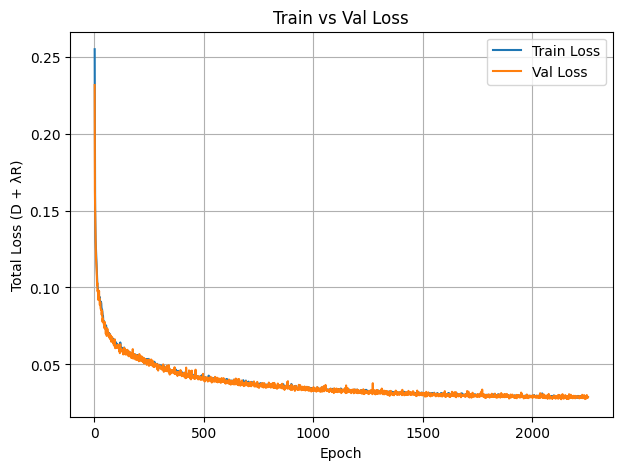

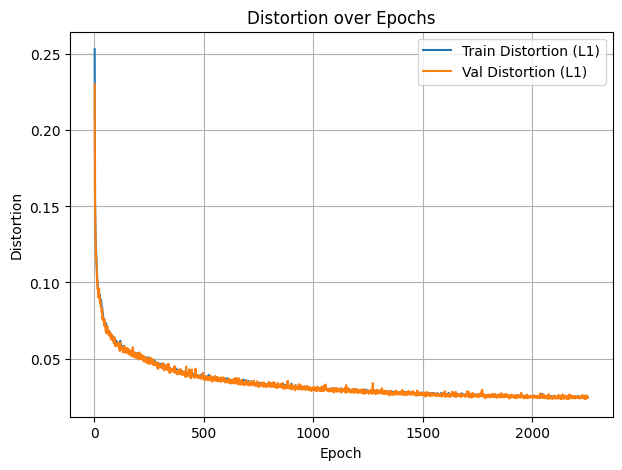

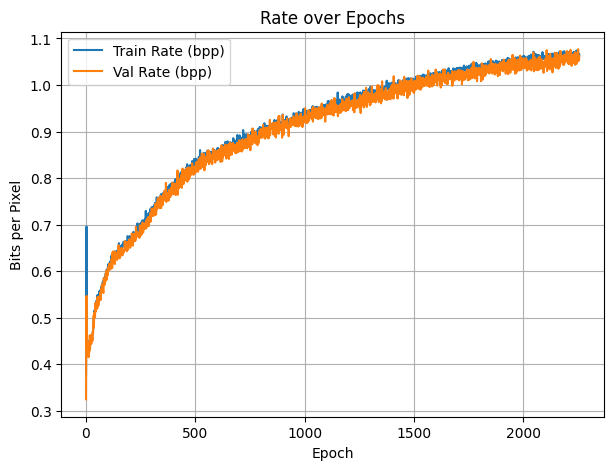

In [17]:
epochs = range(1, len(train_hist) + 1)
train_loss_vals = [t[0] for t in train_hist]
train_D_vals    = [t[1] for t in train_hist]
train_R_vals    = [t[2] for t in train_hist]

val_loss_vals = [v[0] for v in val_hist]
val_D_vals    = [v[1] for v in val_hist]
val_R_vals    = [v[2] for v in val_hist]

plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_vals, label="Train Loss")
plt.plot(epochs, val_loss_vals,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (D + λR)")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, train_D_vals, label="Train Distortion (L1)")
plt.plot(epochs, val_D_vals,   label="Val Distortion (L1)")
plt.xlabel("Epoch")
plt.ylabel("Distortion")
plt.title("Distortion over Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, train_R_vals, label="Train Rate (bpp)")
plt.plot(epochs, val_R_vals,   label="Val Rate (bpp)")
plt.xlabel("Epoch")
plt.ylabel("Bits per Pixel")
plt.title("Rate over Epochs")
plt.legend()
plt.grid(True)
plt.show()


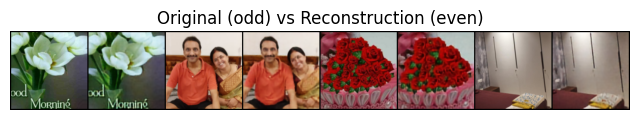

In [18]:
@torch.no_grad()
def show_reconstructions(model, loader, n=4):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    y_t, z_t, mu, sigma, x_hat = model(x, training=False)
    x = x.cpu()
    x_hat = x_hat.cpu()

    # Interleave original and reconstruction
    pairs = []
    for i in range(n):
        pairs.append(x[i])
        pairs.append(x_hat[i])
    grid = vutils.make_grid(pairs, nrow=2*n, normalize=True, value_range=(0,1))

    plt.figure(figsize=(2*n, 4))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.axis("off")
    plt.title("Original (odd) vs Reconstruction (even)")
    plt.show()

show_reconstructions(model, val_loader, n=4)


Testing codec on high-res image: C:\Users\pragnay\OneDrive\Documents\ImageResizer\anders-jilden-AkUR27wtaxs-unsplash.jpg
Image size: 4738 x 3159


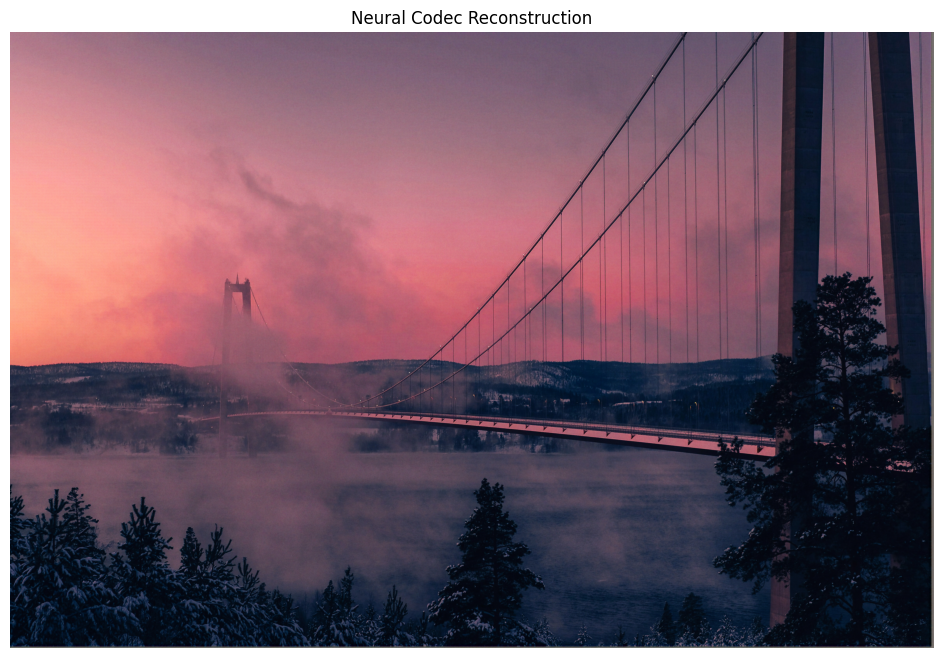

Neural codec latent shape: (1, 96, 198, 297)
Total latent values: 5,645,376
Naive Bits-per-pixel from latent size: 3.0174 bpp

JPEG comparison (quality=75):
JPEG size: 1142.21 KB
JPEG bits-per-pixel: 0.6252 bpp


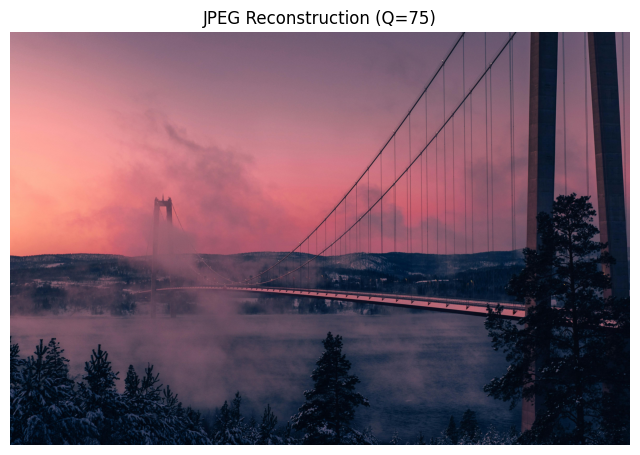

In [19]:
test_image_path = r"C:\Users\pragnay\OneDrive\Documents\ImageResizer\anders-jilden-AkUR27wtaxs-unsplash.jpg"  # CHANGE if needed

if os.path.exists(test_image_path):
    print("\nTesting codec on high-res image:", test_image_path)

    img = Image.open(test_image_path).convert("RGB")
    W, H = img.size
    print("Image size:", W, "x", H)

    to_tensor = T.ToTensor()
    x_full = to_tensor(img).unsqueeze(0).to(device)  # (1,3,H,W)

    with torch.no_grad():
        y = model.g_a(x_full)
        z = model.h_a(y)
        y_q = torch.round(y)
        z_q = torch.round(z)
        mu, sigma = model.h_s(z_q)
        x_hat = model.g_s(y_q)

    x_np = x_full.squeeze(0).cpu().permute(1,2,0).numpy()
    x_hat_np = x_hat.squeeze(0).cpu().permute(1,2,0).numpy()

    # Show side-by-side
    plt.figure(figsize=(16,8))
    plt.imshow(x_hat_np)
    plt.title("Neural Codec Reconstruction")
    plt.axis("off")

    plt.show()

    # Estimate naive bits-per-pixel from latent size (no entropy coding yet)
    num_latent = y_q.numel()
    bpp_latent = (num_latent * 8) / (H * W)
    print(f"Neural codec latent shape: {tuple(y_q.shape)}")
    print(f"Total latent values: {num_latent:,}")
    print(f"Naive Bits-per-pixel from latent size: {bpp_latent:.4f} bpp")

    # JPEG comparison at quality=75
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=75)
    jpeg_bytes = buf.getvalue()
    jpeg_bpp = (len(jpeg_bytes) * 8) / (H * W)

    print("\nJPEG comparison (quality=75):")
    print(f"JPEG size: {len(jpeg_bytes)/1024:.2f} KB")
    print(f"JPEG bits-per-pixel: {jpeg_bpp:.4f} bpp")

    jpeg_img = Image.open(io.BytesIO(jpeg_bytes)).convert("RGB")
    jpeg_np = np.array(jpeg_img).astype(np.float32) / 255.0

    plt.figure(figsize=(8,8))
    plt.imshow(jpeg_np)
    plt.title("JPEG Reconstruction (Q=75)")
    plt.axis("off")
    plt.show()
else:
    print("\nHigh-res test image not found. Set 'test_image_path' to a valid file if you want to test.")